<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-academic-stress-dataset-ml-48?scriptVersionId=255554221" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-academic-stress-real-world-dataset/academicStress.csv


## Title:
Student Academic Stress Dataset

## Description:
This dataset captures real-world information on academic stress levels among students, reflecting the psychological, emotional, and behavioral impact of academic life. It includes factors such as study workload, exam pressure, time management, peer competition, sleep patterns, and mental health indicators. The data can be used to analyze the relationship between academic demands and student well-being, identify stress triggers, and develop predictive models for early stress detection. Potential applications include educational research, mental health interventions, and the design of stress-reduction programs in schools and universities.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/student-academic-stress-real-world-dataset/academicStress.csv")

In [3]:
df.head()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [4]:
df.tail()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
116,26/07/2025 22:11:02,high school,3,1,Noisy,Analyze the situation and handle it with intel...,No,4,4
117,27/07/2025 13:45:00,undergraduate,2,3,Noisy,Analyze the situation and handle it with intel...,No,3,5
118,27/07/2025 22:56:54,high school,2,2,Peaceful,Analyze the situation and handle it with intel...,No,4,4
119,30/07/2025 06:43:55,high school,4,5,Peaceful,Analyze the situation and handle it with intel...,No,3,5
120,30/07/2025 16:02:16,undergraduate,4,4,disrupted,Analyze the situation and handle it with intel...,No,4,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            121 non-null    object
 1   Your Academic Stage                                                  121 non-null    object
 2   Peer pressure                                                        121 non-null    int64 
 3   Academic pressure from your home                                     121 non-null    int64 
 4   Study Environment                                                    121 non-null    object
 5   What coping strategy you use as a student?                           121 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  121 non-null    object
 7   What would you rat

In [6]:
df.describe()

,Peer pressure,Academic pressure from your home,What would you rate the academic competition in your student life,Rate your academic stress index
count,121.000000,121.000000,121.000000,121.000000
mean,3.008264,3.190083,3.553719,3.669421
std,1.083942,1.260384,0.991215,1.059783
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

Timestamp                                                              0
Your Academic Stage                                                    0
Peer pressure                                                          0
Academic pressure from your home                                       0
Study Environment                                                      0
What coping strategy you use as a student?                             0
Do you have any bad habits like smoking, drinking on a daily basis?    0
What would you rate the academic  competition in your student life     0
Rate your academic stress index                                        0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Timestamp                                                              object
Your Academic Stage                                                    object
Peer pressure                                                           int64
Academic pressure from your home                                        int64
Study Environment                                                      object
What coping strategy you use as a student?                             object
Do you have any bad habits like smoking, drinking on a daily basis?    object
What would you rate the academic  competition in your student life      int64
Rate your academic stress index                                         int64
dtype: object

In [10]:
df.shape

(121, 9)

In [11]:
df.columns

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index '],
      dtype='object')

## Data visualizations

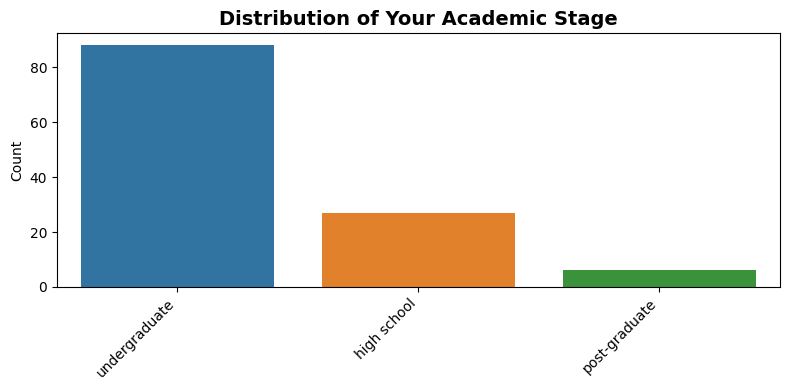

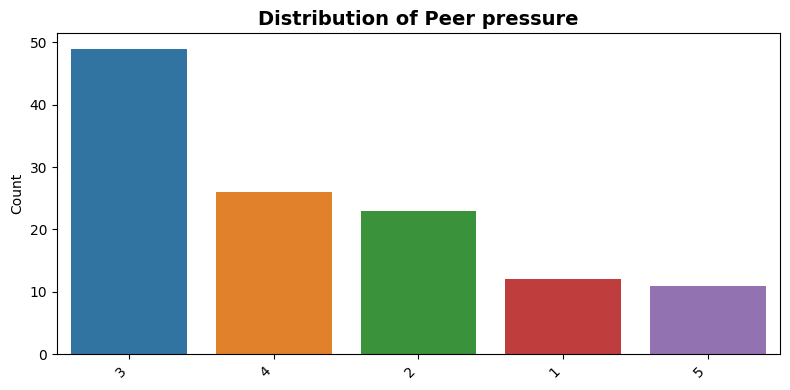

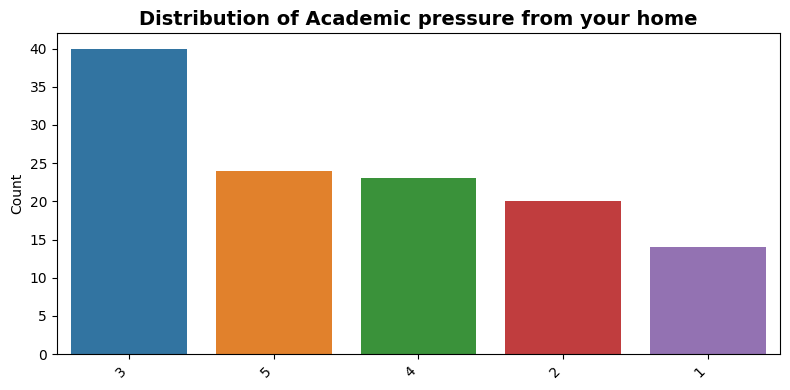

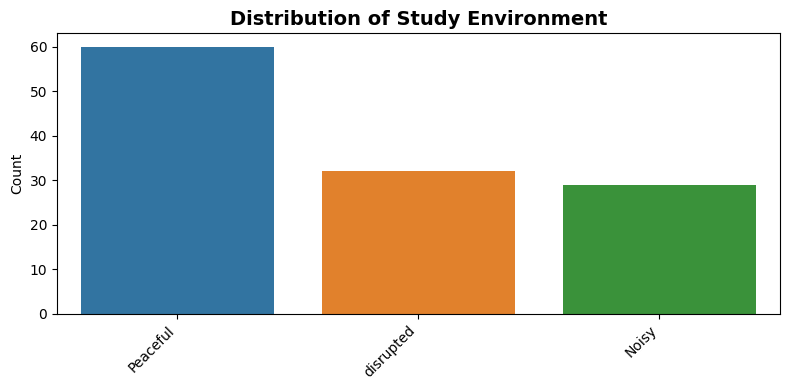

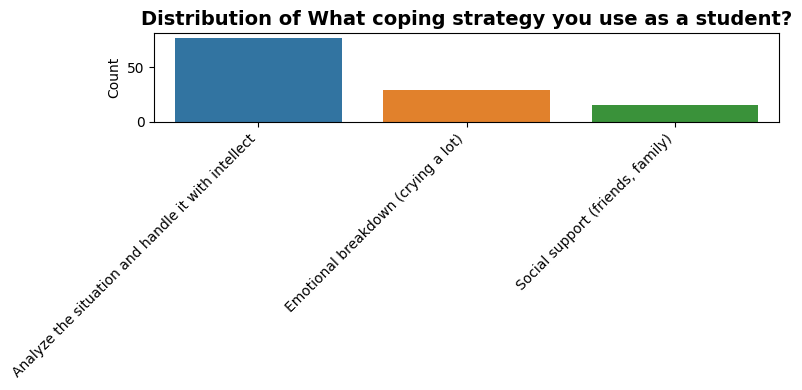

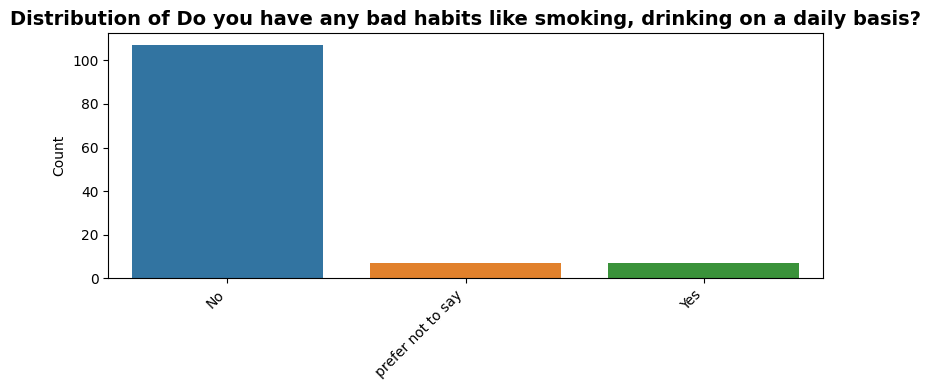

In [12]:
# 2. Visualization for categorical features
categorical_cols = [
    'Your Academic Stage',
    'Peer pressure',
    'Academic pressure from your home',
    'Study Environment',
    'What coping strategy you use as a student?',
    'Do you have any bad habits like smoking, drinking on a daily basis?'
]

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


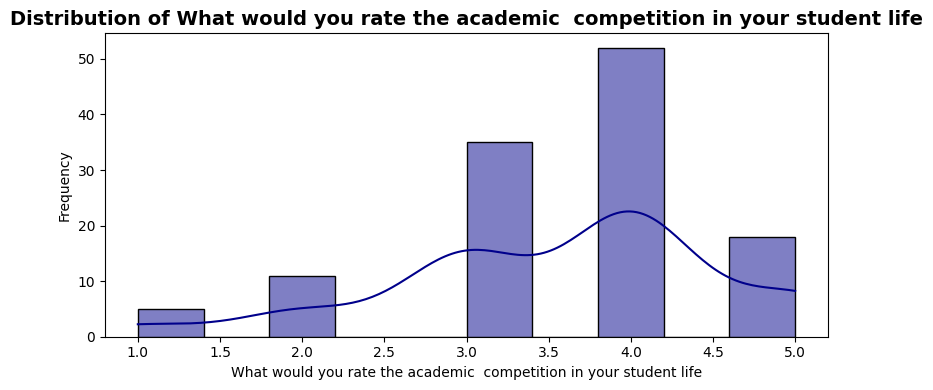

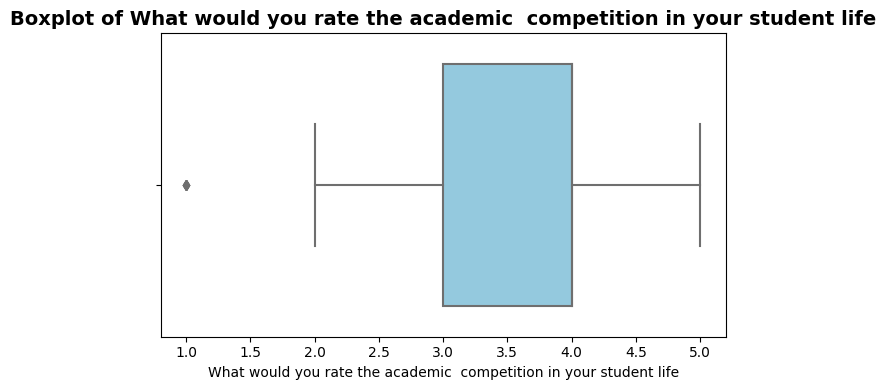

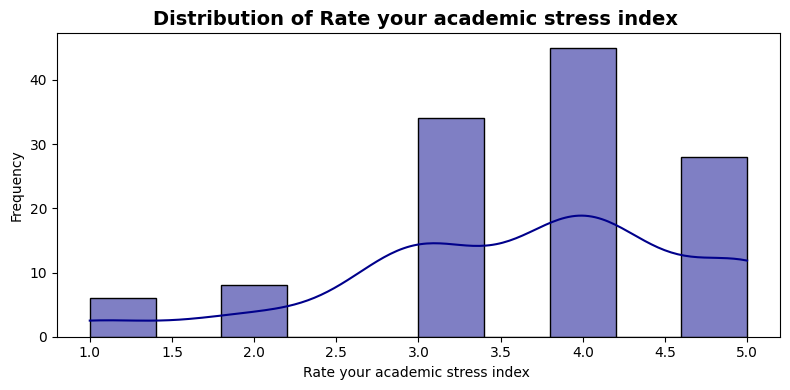

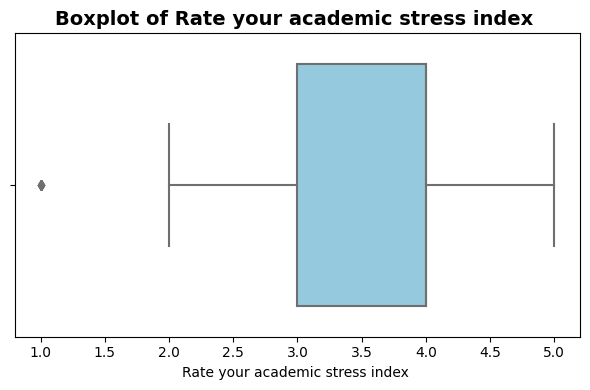

In [13]:
# 3. Visualization for numeric features
numeric_cols = [
    'What would you rate the academic  competition in your student life',
    'Rate your academic stress index '
]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=10, color='darkblue')
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Boxplot to check outliers
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


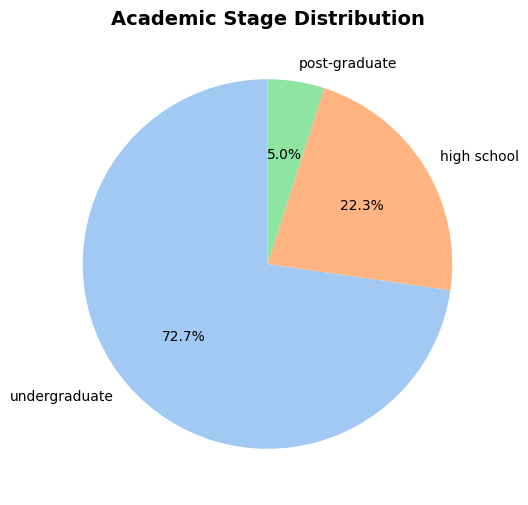

In [14]:
# 4. Pie chart for Academic Stage
plt.figure(figsize=(6, 6))
df['Your Academic Stage'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel")
)
plt.title("Academic Stage Distribution", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.show()

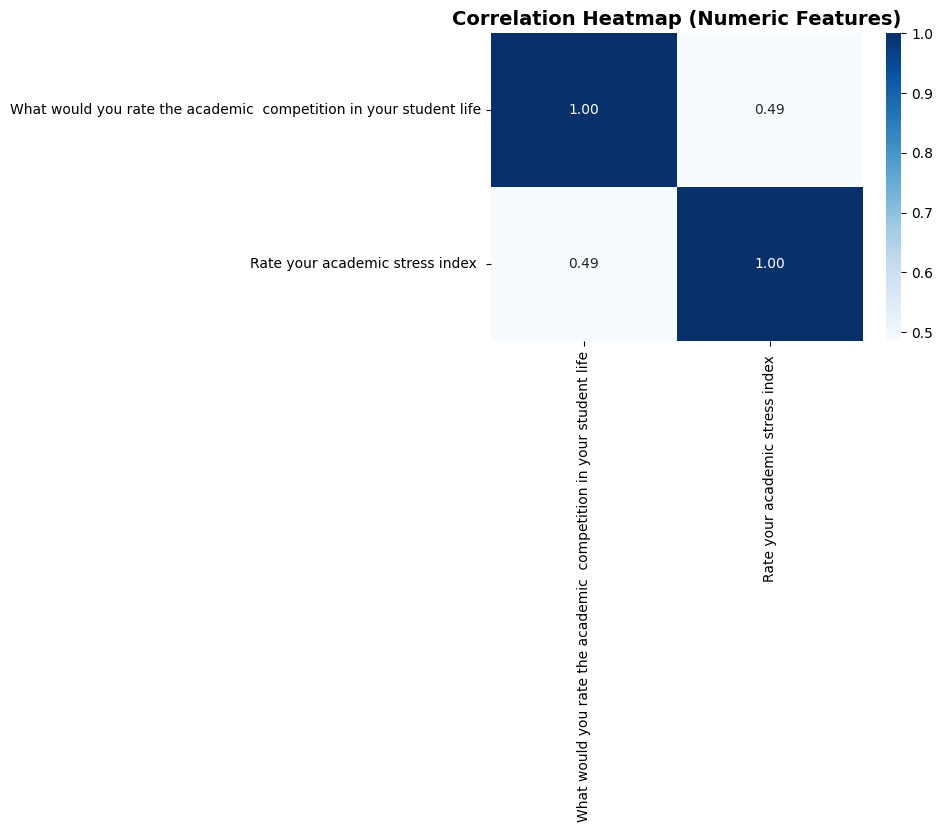

In [15]:
# 5. Correlation heatmap (numeric only)
plt.figure(figsize=(6, 4))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)", fontsize=14, fontweight='bold')
plt.show()

## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [17]:
# 2. Handle missing values
df = df.dropna()

# 3. Label Encoding for categorical variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 4. Define Features (X) and Target (y)
X = df.drop(columns=['Rate your academic stress index '])
y = df['Rate your academic stress index ']

# If target is numeric continuous, convert to classification labels
y = pd.qcut(y, q=3, labels=["Low", "Medium", "High"])
y = LabelEncoder().fit_transform(y)

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# 6. Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# 7. Train and evaluate
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = acc
    print(f"{name}: {acc:.2f}%")


Logistic Regression: 36.00%
Decision Tree: 36.00%
Random Forest: 48.00%
Naive Bayes: 44.00%
SVM: 28.00%
KNN: 28.00%


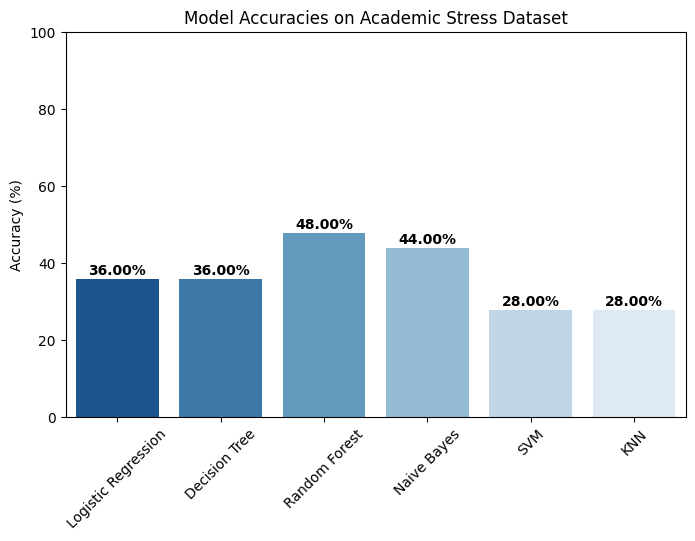

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette="Blues_r")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracies on Academic Stress Dataset")
plt.xticks(rotation=45)
plt.ylim(0, 100)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

## THank you...pls upvote!!!!